<div>

<h1><b>Inferência Estatística</b></h1>

</div>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st

<div style='font-size:26px'>

**Questão 1 — Conceitos Fundamentais**
</div>


- População:
    * refere-se ao universo completo de elementos sob estudo.

**Exemplo:**
o universo completo corresponde a 50.000 habitantes.


- Amostra:
    * representa uma parcela da população escolhida para realizar as análises e conclusões.


**Exemplo:**
um grupo representativo extraído da população contém 100 indivíduos.


- Parâmetro populacional
    * trata-se de um valor numérico que descreve uma propriedade do conjunto total da população.


**Exemplo:**
o peso médio de todos os 50.000 habitantes.


- Estatística amostral
    * é um valor numérico obtido a partir dos dados da amostra, utilizado para estimar o parâmetro. Seu resultado oscila conforme a amostra selecionada.


**Exemplo:**
o peso médio calculado para o grupo de 100 indivíduos.





<div style='font-size:26px'>

**Questão 2 — Média Amostral em Python**
</div>


```python
    dados = [12, 15, 18, 20, 22, 25]
```

- Cálculo manual da média amostral:

$\bar x = \frac{12 + 15 + 18 + 20 + 22 + 25}{6} = \frac{112}{6} \approx 18.6$

- Obtenção da média via código:
```python
    np.mean()
```


<div style='font-size:26px'>

**Questão 3 — Erro Amostral**
</div>


**Duas amostras apresentam médias distintas em razão da variabilidade inerente ao processo amostral, uma vez que a composição dos elementos selecionados muda de uma amostra para outra.**


<div style='font-size:26px'>

**Questão 4 — Simulação de Médias Amostrais**
</div>

In [3]:
SEMENTE = 28
np.random.seed(SEMENTE)

N_POP = 1000
N_AMOSTRAS = 100
TAM_AMOSTRA = 30

pop = np.random.normal(loc=50, scale=10, size=N_POP)

lista_medias = []
for _ in range(N_AMOSTRAS):
    amostra = np.random.choice(pop, size=TAM_AMOSTRA, replace=False)
    lista_medias.append(np.mean(amostra))

media_geral = np.mean(lista_medias)
print(f'Média das médias amostrais: {media_geral:.2f}')

Média das médias amostrais: 49.64


<div style='font-size:26px'>

**Questão 5 — Distribuição Amostral**
</div>


- O que é: A distribuição amostral da média corresponde à distribuição de probabilidade formada por todas as médias possíveis, calculadas a partir de amostras de tamanho fixo retiradas de uma mesma população.

- Importância para a Inferência: Ela constitui o alicerce de toda análise inferencial. Revela como as médias amostrais se distribuem e o quanto elas tendem a se afastar do parâmetro real da população, possibilitando mensurar a incerteza presente nas estimativas.


<div style='font-size:26px'>

**Questão 6 — Intervalo de Confiança**
</div>

$IC_{95\%} = [12.4, 18.7]$

<div style='font-size:20px'>

- Significado: Um intervalo de confiança de 95% quer dizer que, ao repetir o procedimento de amostragem e construção do intervalo inúmeras vezes, cerca de 95 a cada 100 intervalos obtidos iriam capturar o verdadeiro valor do parâmetro populacional.

- Interpretação: Com base nos dados, afirma-se com 95% de confiança que o parâmetro populacional real encontra-se entre 12.4 e 18.7. Isso não implica que há 95% de probabilidade de o parâmetro estar nesse intervalo específico, mas sim que o procedimento utilizado para construí-lo é eficaz em 95% das situações.
</div>


<div style='font-size:26px'>

**Questão 7 — Erro Padrão**
</div>

**dados = [5, 8, 9, 10, 12, 15, 18]**

In [5]:
amostra_q7 = [5, 8, 9, 10, 12, 15, 18]

dp = np.std(amostra_q7, ddof=0)
tamanho = len(amostra_q7)
ep = dp / np.sqrt(tamanho)

print(f'a) Desvio padrão amostral: {dp:.2f}')
print(f'b) Erro padrão da média: {ep:.2f}')

a) Desvio padrão amostral: 4.07
b) Erro padrão da média: 1.54


<div style='font-size:26px'>

**Questão 8 — Interpretação do Erro Padrão**
</div>



**O erro padrão se reduz à medida que o tamanho da amostra cresce, pois amostras maiores carregam mais informação sobre a população, o que diminui a imprecisão e torna a média estimada mais confiável e consistente.**




<div style='font-size:26px'>

**Questão 9 — Teorema Central do Limite**
</div>

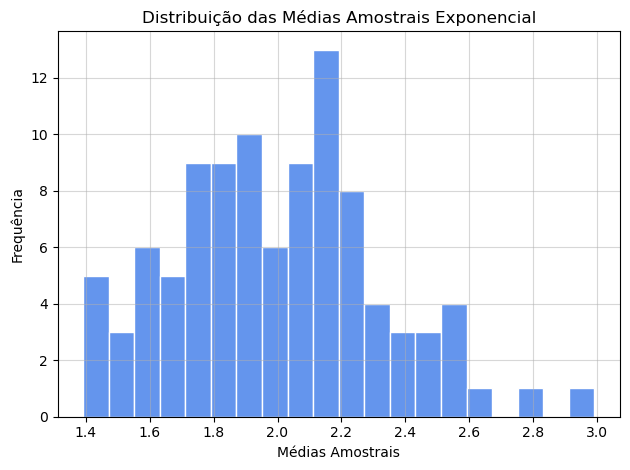

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(28)

n = 40
repeticoes = 100
escala = 2

medias_exp = [
    np.mean(np.random.exponential(scale=escala, size=n))
    for _ in range(repeticoes)
]

plt.figure()
plt.hist(medias_exp, bins=20, color='cornflowerblue', edgecolor='white')
plt.title('Distribuição das Médias Amostrais Exponencial')
plt.xlabel('Médias Amostrais')
plt.ylabel('Frequência')
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()



**Ainda que a distribuição original dos dados seja bastante assimétrica, o histograma construído a partir das médias amostrais se aproxima de uma Distribuição Normal. Isso demonstra na prática o Teorema Central do Limite: conforme o tamanho das amostras aumenta, a distribuição das médias tende a assumir o formato de uma curva normal.**



<div style='font-size:26px'>

**Questão 10 — Comparação entre Amostras**
</div>



*O Estudo B tende a gerar estimativas mais confiáveis e consistentes.* amostras de maior dimensão reduzem a variação das estimativas entre diferentes amostras. Por contar com um número muito maior de observações, o Estudo B atenua a influência de valores extremos e resulta em um erro amostral consideravelmente menor.




<div style='font-size:26px'>

**Questão 11 — Intervalo de Confiança com SciPy**
</div>

In [7]:
obs = [22, 25, 21, 20, 26, 24, 23, 27]

media_obs = np.mean(obs)
ep_obs = st.sem(obs)
gl = len(obs) - 1
nivel = 0.95

lim_inf, lim_sup = st.t.interval(confidence=nivel, df=gl, loc=media_obs, scale=ep_obs)

print(f'Média amostral: {media_obs:.2f}')
print(f'Intervalo de Confiança de 95%: [{lim_inf:.2f}, {lim_sup:.2f}]')

Média amostral: 23.50
Intervalo de Confiança de 95%: [21.45, 25.55]


<div style='font-size:26px'>

**Questão 12 — Precisão da Estimativa**
</div>


*A Pesquisa A demonstra maior exatidão na estimativa.* A exatidão de um intervalo de confiança é avaliada pela amplitude entre seus limites inferior e superior. Quanto mais estreito for o intervalo, menor é a margem de erro associada e mais refinada é a estimativa obtida.



<div style='font-size:26px'>

**Questão 13 — Variabilidade das Médias**
</div>

In [10]:
np.random.seed(42)
pop_base = np.random.normal(loc=50, scale=10, size=1000)

def gerar_medias(populacao, tam_amostra, n_rep=50):
    return [np.mean(np.random.choice(populacao, size=tam_amostra)) for _ in range(n_rep)]

medias_pequenas = gerar_medias(pop_base, tam_amostra=5)
medias_grandes  = gerar_medias(pop_base, tam_amostra=100)

dp_pequenas = np.std(medias_pequenas)
dp_grandes  = np.std(medias_grandes)

print(f'Desvio Padrão das médias (n=5): {dp_pequenas:.4f}')
print(f'Desvio Padrão das médias (n=100): {dp_grandes:.4f}')

Desvio Padrão das médias (n=5): 3.6561
Desvio Padrão das médias (n=100): 0.9393


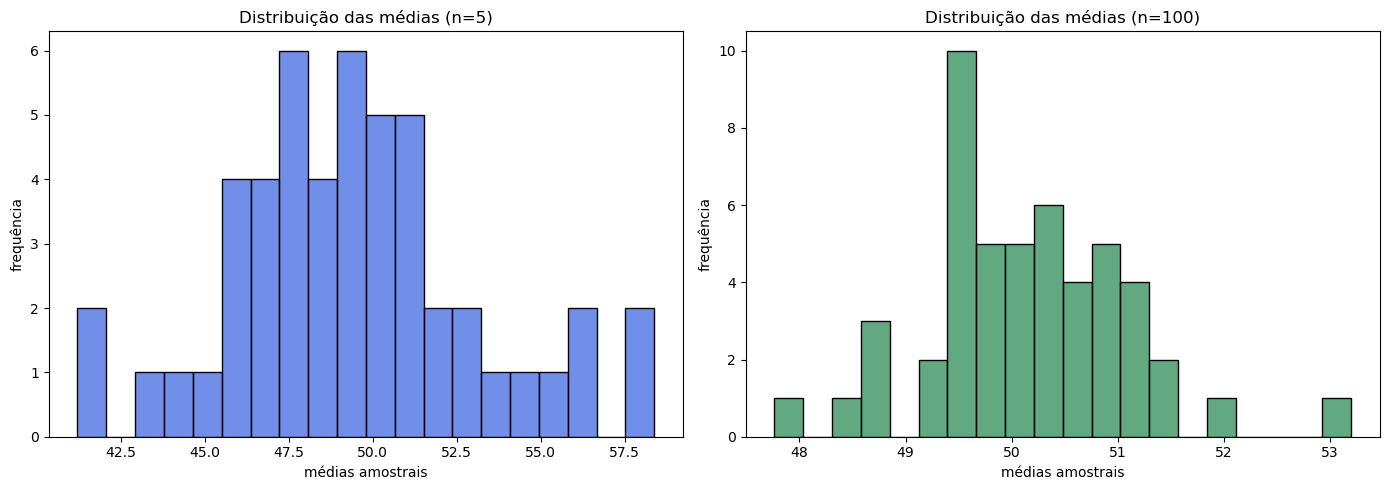

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(medias_pequenas, bins=20 , color='royalblue', ax=ax1)
ax1.set_title('Distribuição das médias (n=5)')
ax1.set_xlabel('médias amostrais')
ax1.set_ylabel('frequência')

sns.histplot(medias_grandes, bins=20, color='seagreen', ax=ax2)
ax2.set_title('Distribuição das médias (n=100)')
ax2.set_xlabel('médias amostrais')
ax2.set_ylabel('frequência')

plt.tight_layout()
plt.show()



- **A variabilidade das médias cai de forma expressiva. As médias obtidas de amostras com 100 elementos ficam muito mais agrupadas em torno da média real da população.**
- **Por outro lado, as médias baseadas em amostras de tamanho 5 se dispersam amplamente, evidenciando alta instabilidade.**




<div style='font-size:26px'>

**Questão 14 — Estimativa Pontual e Intervalar**
</div>

**Estimativa Pontual:** É um único valor calculado a partir de uma amostra e utilizado como melhor aproximação para um parâmetro da população.

Exemplo: Ao analisar uma amostra de produtos fabricados em uma indústria, obtém-se um peso médio de 502 g. Esse valor é utilizado como estimativa da média de peso de todos os produtos produzidos.

**Estimativa Intervalar:** É um intervalo de valores obtido a partir dos dados amostrais, que fornece uma faixa plausível para o parâmetro populacional, associada a um nível de confiança.

Exemplo: Após medir a altura de uma amostra de árvores de uma floresta, conclui-se com 95% de confiança que a altura média de todas as árvores está entre 11,8 m e 13,2 m.